# 3D Spleen Volumetric Segmentation from CT Scans
**Author:** Vasilis Kourentzis | **Domain:** Abdominal Radiology / General Surgery

### Executive Summary
This notebook outlines a high-performance, GPU-accelerated pipeline for the automated volumetric segmentation of the spleen from patient CT scans. By accurately mapping organ boundaries in 3D space, this tool aims to assist clinicians in rapid organ volumetry and trauma assessment.

### Methodology & Tech Stack
* **Dataset:** Medical Segmentation Decathlon (MSD) Spleen Dataset.
* **Processing Engine:** Built on **PyTorch** and **MONAI** to handle large-scale CT dataset extraction, 3D tensor augmentations, and batch loading.
* **Visualization:** Renders AI-generated volumetric masks over raw clinical data. Utilizes customized colormaps (e.g., Jet) to maximize visual contrast between segmented regions and surrounding visceral tissue, allowing for rapid qualitative validation by clinicians.

In [ ]:
# Preparing the dataset
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from monai.apps import DecathlonDataset
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    RandCropByPosNegLabeld
)

# 1. Setup GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Engine Active: {torch.cuda.get_device_name(0)}")

# 2. Define Transforms
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164),
])

# 3. Download Data
# This will download ~1.5GB. It might take 2-5 minutes.
print("Downloading Spleen CT Dataset...")
root_dir = "./data"
train_ds = DecathlonDataset(
    root_dir=root_dir, 
    task="Task09_Spleen", 
    section="training", 
    transform=train_transforms, 
    download=True,
    cache_rate=0.0 
)
print(f"Dataset Ready. Total Patients: {len(train_ds)}")



Image Shape: torch.Size([1, 500, 500, 271])


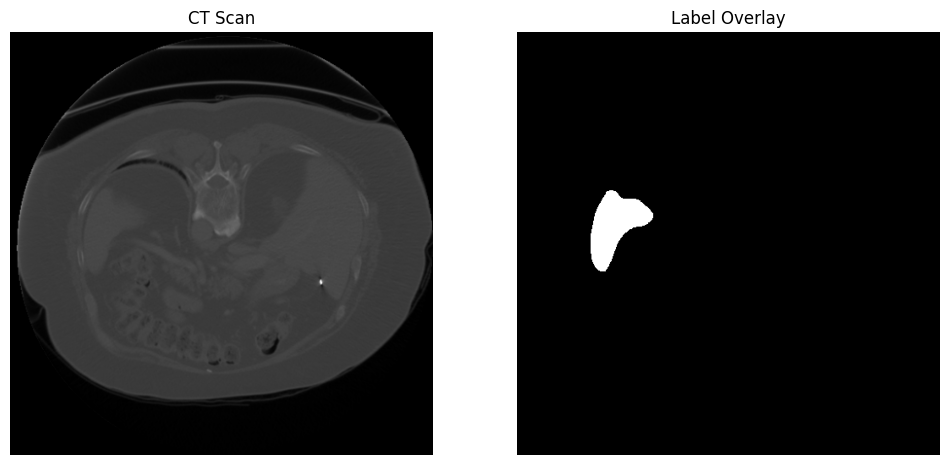

In [ ]:
# Visualize Patient 0
data = train_ds[0]
image = data["image"]
label = data["label"]

print(f"Image Shape: {image.shape}") 
# Expected: (1, H, W, D) -> CT is grayscale only.


# Visualization Function
def show_ct(img, lbl, slice_idx):
    plt.figure(figsize=(12, 6))
    title = ["CT Scan"]
    
    
    plt.subplot(1, 2, 1)
    plt.title(title[0])
    plt.imshow(img[0, :, :, slice_idx].T, cmap="gray")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Label Overlay")
    plt.imshow(lbl[0, :, :, slice_idx].T, cmap="gray")
    plt.axis('off')

    plt.show()

# Visualize
show_ct(image, label, slice_idx=135)

Spleen found between slices 113 and 197.
Showing Center Slice: 155


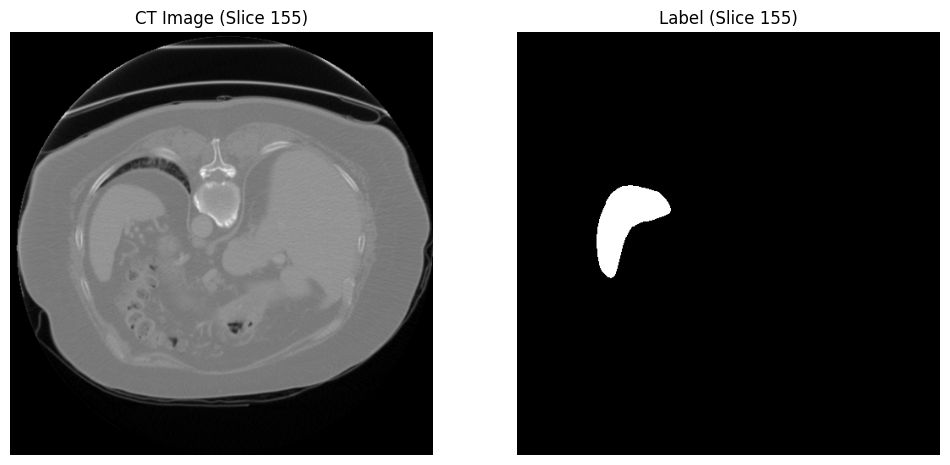

In [ ]:
# Visualizing the slice where spleen exists
import numpy as np

def show_specific_slice(img, lbl, target_label_idx=1):
    # 1. Find where the label is NOT zero
    # np.where returns coordinates (x, y, z) where condition is true
    coords = np.where(lbl[0] == target_label_idx)
    
    if len(coords[0]) == 0:
        print("Error: No Spleen found in this patient! (Label is all black)")
        return

    # 2. Find the center slice along the Z-axis (depth)
    min_z = np.min(coords[2])
    max_z = np.max(coords[2])
    center_z = (min_z + max_z) // 2
    
    print(f"Spleen found between slices {min_z} and {max_z}.")
    print(f"Showing Center Slice: {center_z}")

    plt.figure(figsize=(12, 6))
    
    # CT Image
    plt.subplot(1, 2, 1)
    plt.title(f"CT Image (Slice {center_z})")
    plt.imshow(img[0, :, :, center_z].T, cmap="gray")
    plt.axis('off')

    # Label
    plt.subplot(1, 2, 2)
    plt.title(f"Label (Slice {center_z})")
    plt.imshow(lbl[0, :, :, center_z].T, cmap="gray")
    plt.axis('off')

    plt.show()

# Run it on the data you already loaded
show_specific_slice(image, label)

Reloading Spleen Dataset with Windowing...
Spleen found between slices 174 and 201.
Showing Center Slice: 187


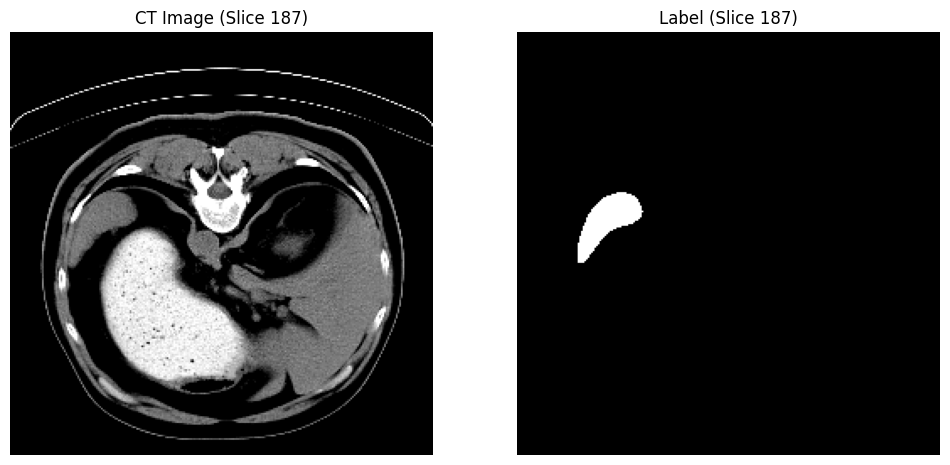

In [ ]:
# Clipping the soft tissue window (-57,164 HU)
from monai.transforms import ScaleIntensityRanged

# 1. Update Transforms with Physics-aware Scaling

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    
    # --- THE FIX ---
    # We clip to the "Soft Tissue Window"
    # a_min=-57, a_max=164: The range where organs live.
    # b_min=0.0, b_max=1.0: Map that range to 0-1 for the AI.
    # clip=True: Anything outside the range is hard-clamped.
    ScaleIntensityRanged(
        keys=["image"], 
        a_min=-57, 
        a_max=164, 
        b_min=0.0, 
        b_max=1.0, 
        clip=True
    ),
    # ----------------
    
    # Add cropping now so we are ready for training
    # RandCropByPosNegLabeld(
    #     keys=["image", "label"],
    #     label_key="label",
    #     spatial_size=(96, 96, 96),
    #     pos=1,
    #     neg=1,
    #     num_samples=4,
    #     image_key="image",
    #     image_threshold=0,
    # ),
])

# 2. Reload Data
# Since we changed transforms, we must re-initialize the dataset
print("Reloading Spleen Dataset with Windowing...")
train_ds = DecathlonDataset(
    root_dir="./data", 
    task="Task09_Spleen", 
    section="training", 
    transform=train_transforms, 
    download=False, # Already downloaded
    cache_rate=0.0 
)

# 3. Visualize Again
# We use the same 'show_specific_slice' function from before
data = train_ds[1]
image = data["image"]
label = data["label"]   
show_specific_slice(image, label)

In [ ]:
# Building and training the model
from monai.data import load_decathlon_datalist
from monai.data import DataLoader, CacheDataset, decollate_batch
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged, # Use the Ranged scaler for CT
    RandCropByPosNegLabeld,
    RandFlipd,
)

# 1. Define Training Transforms (Physics + Cropping)
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.5, 1.5, 2.0), mode=("bilinear", "nearest")),
    
    # Physics Windowing (Soft Tissue)
    ScaleIntensityRanged(
        keys=["image"], a_min=-57, a_max=164, 
        b_min=0.0, b_max=1.0, clip=True
    ),
    
    # Smart Cropping (96x96x96)
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),
        pos=1,
        neg=1,
        num_samples=4,
        image_key="image",
        image_threshold=0,
    ),
])

# 2. Get Clean File List (The Robust Fix)
# We load the paths directly from the JSON file to avoid "Double Load" errors.
json_path = "./data/Task09_Spleen/dataset.json"

print("Loading raw file list from JSON...")
train_files = load_decathlon_datalist(json_path, is_segmentation=True, data_list_key="training")
train_files = train_files[:20] # Use first 20 patients for speed

print("Initializing Cache (Moving Spleen CTs to RAM)...")
train_loader = DataLoader(
    CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0), 
    batch_size=2, 
    shuffle=True,
    num_workers=0
)

# 3. Build Model (3D U-Net)
# in_channels=1 (CT is grayscale)
# out_channels=2 (Background, Spleen)
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)

loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4)

# 4. Run Training (5 Epochs)
max_epochs = 100
print(f"--- Starting Spleen Training ---")

for epoch in range(max_epochs):
    print(f"Epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        if step % 5 == 0:
            print(f"  Step {step}, Loss: {loss.item():.4f}", end="\r")

    epoch_loss /= step
    print(f"\nEpoch {epoch + 1} Average Loss: {epoch_loss:.4f}")

print("Spleen Model Trained.")

Loading raw file list from JSON...
Initializing Cache (Moving Spleen CTs to RAM)...


Loading dataset: 100%|██████████| 20/20 [00:26<00:00,  1.34s/it]


--- Starting Spleen Training ---
Epoch 1/100
  Step 10, Loss: 0.6167
Epoch 1 Average Loss: 0.6168
Epoch 2/100
  Step 10, Loss: 0.5958
Epoch 2 Average Loss: 0.5905
Epoch 3/100
  Step 10, Loss: 0.5581
Epoch 3 Average Loss: 0.5784
Epoch 4/100
  Step 10, Loss: 0.5428
Epoch 4 Average Loss: 0.5764
Epoch 5/100
  Step 10, Loss: 0.5511
Epoch 5 Average Loss: 0.5678
Epoch 6/100
  Step 10, Loss: 0.5480
Epoch 6 Average Loss: 0.5577
Epoch 7/100
  Step 10, Loss: 0.5608
Epoch 7 Average Loss: 0.5572
Epoch 8/100
  Step 10, Loss: 0.5783
Epoch 8 Average Loss: 0.5544
Epoch 9/100
  Step 10, Loss: 0.5349
Epoch 9 Average Loss: 0.5431
Epoch 10/100
  Step 10, Loss: 0.5420
Epoch 10 Average Loss: 0.5428
Epoch 11/100
  Step 10, Loss: 0.5538
Epoch 11 Average Loss: 0.5450
Epoch 12/100
  Step 10, Loss: 0.5537
Epoch 12 Average Loss: 0.5288
Epoch 13/100
  Step 10, Loss: 0.5109
Epoch 13 Average Loss: 0.5159
Epoch 14/100
  Step 10, Loss: 0.5116
Epoch 14 Average Loss: 0.5273
Epoch 15/100
  Step 10, Loss: 0.5050
Epoch 15 A

Scanning patient...


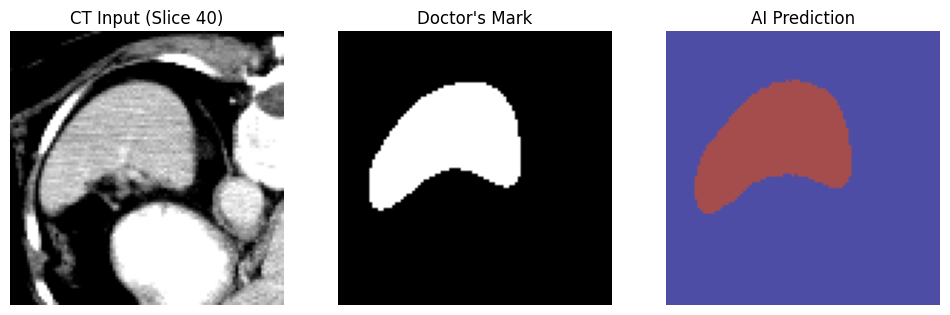

In [ ]:
# Prediction to a random patient and visualizing
import matplotlib.pyplot as plt

# 1. Switch to Eval Mode
model.eval()

# 2. Get a patient from the loader
# We grab the first batch (2 patients) and pick the first one
data_iter = iter(train_loader)
batch_data = next(data_iter)
images, labels = batch_data["image"].to(device), batch_data["label"].to(device)

# 3. Predict (Sliding Window)
# The spleen is bigger than 96x96, so the AI stitches crops together
print("Scanning patient...")
with torch.no_grad():
    outputs = sliding_window_inference(
        inputs=images, 
        roi_size=(96, 96, 96), 
        sw_batch_size=4, 
        predictor=model
    )

# 4. Post-Process
# Sigmoid -> Probability. Threshold > 0.5 -> Mask.
probs = torch.sigmoid(outputs)
preds = (probs > 0.5).float()

# 5. Find the Best Slice to Show (Center of the Spleen)
# We use the label to find where the spleen actually is
lbl_cpu = labels[0, 0].cpu().numpy()
coords = np.where(lbl_cpu == 1)

if len(coords[0]) > 0:
    slice_idx = int(np.mean(coords[2])) # Middle of the spleen
else:
    slice_idx = 50 # Fallback

# 6. Visualize
plt.figure(figsize=(12, 6))

# A. CT Input (Windowed)
plt.subplot(1, 3, 1)
plt.title(f"CT Input (Slice {slice_idx})")
plt.imshow(images[0, 0, :, :, slice_idx].cpu().T, cmap="gray")
plt.axis("off")

# B. Ground Truth
plt.subplot(1, 3, 2)
plt.title("Doctor's Mark")
plt.imshow(labels[0, 0, :, :, slice_idx].cpu().T, cmap="gray")
plt.axis("off")

# C. AI Prediction
plt.subplot(1, 3, 3)
plt.title("AI Prediction")
plt.imshow(preds[0, 1, :, :, slice_idx].cpu().T, cmap="jet", alpha=0.7) # Jet colormap makes it pop
plt.axis("off")

plt.show()

In [ ]:
# Saving model
torch.save(model.state_dict(), "spleen_volume_screener.pth")
print("Model saved successfully.")

Model saved successfully.
